# Mark-Twain -- a quantitative teardown of the October effect
### ^GSPC 1928-2026 | Welch t | HAC inference | crash-strip robustness | permutation null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![October_dangerous%3F: Myth](https://img.shields.io/badge/October_dangerous%3F-Myth-8b949e?style=flat-square)

The rigorous companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its standard error and its robustness check. We test (A) whether October's mean return is significantly negative, (B) whether it is significantly below the other eleven months, (C) whether either fact survives removing the three famous crash months, and (D) whether October's elevated volatility is structural or a single-event artefact.

> **Not investment advice.** Real data: ^GSPC daily auto-adjusted closes, Yahoo Finance, 1928-01-04 to 2026-06-12 (n=24,727). Fingerprint `f47bc6e2a2f4`. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mark_twain import data, strategy as st

HAVE_REAL = False
try:
    ret = data.fetch_daily()
    HAVE_REAL = len(ret) > 0
except Exception:
    ret = None

print("real ^GSPC cache present:", HAVE_REAL)


real ^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | October mean **++2.92 bps/day**, HAC t = **+0.95**; Welch t vs the rest = **-0.072**. Permutation p = **0.47** (Oct sits at the median). |
| **Tradability** | `MIRAGE` | October is a *positive* month; avoiding it reduces returns, not risk. No signal, no trade. |
| **October dangerous?** | `MYTH` | Strip 1929/1987/2008: Oct rises to **+5.7 bps/day**, Welch t = +0.853. September is the genuine underperformer (HAC t = -2.0). |

> Three crashes gave October a press agent. The underlying distribution is unremarkable.

## 1 - The claim, steelmanned

Three concrete sub-claims underlie the October-effect reputation:

- **H_A (return).** $E[r_{Oct}] < E[r_{other}]$ -- October mean daily return is significantly below the other eleven months.
- **H_B (volatility).** $\sigma_{Oct} > \sigma_{other}$ -- October intraday volatility is anomalously high, beyond what the crash-event arithmetic implies.
- **H_C (robustness).** Both effects persist after removing the three canonical crashes (1929-10, 1987-10, 2008-10) -- i.e., they are structural, not anecdotal.

We reject H_A and H_C on the real tape and accept H_B only as a single-event artefact, not a structural feature.

## 2 - So what? -- what rides on each answer

If H_A held, a calendar rule (cash in October, equities otherwise) would have a positive risk-adjusted return over nearly a century. That would be a remarkable free lunch -- and an embarrassment for semi-strong market efficiency. The more interesting failure is *why* the reputation survives: the three crash months are so vivid (and so concentrated in October) that they dominate the memory of every practitioner who lived through them, while the 90+ uneventful Octobers disappear into the base rate. This is textbook **availability bias** dressed as empirical research.

## 3 - Protocol

- **Data.** ^GSPC daily close-to-close returns (Yahoo auto-adjusted), 1928-2026, n = 24,727 trading days.
- **Monthly stats.** Per-month mean, annualised vol, worst day, and Newey-West HAC t-stat on the within-month daily mean.
- **Primary test.** Welch t: October daily returns vs the other eleven months. Threshold |t| >= 2 to call 'significant'.
- **Robustness.** Repeat with crash months removed (1929-10, 1987-10, 2008-10). A structural signal should survive the removal of three months in a 95-year record.
- **Permutation null.** Shuffle month labels 5,000 times; record the fraction of random months with mean <= October's observed mean. A genuinely anomalous month should score a low percentile.
- **Positive control.** Synthetic tape with a planted October drag: the analysis should recover the signal when it is there.

## 4 - The teardown

### 4a - Per-month HAC inference -- all twelve months

HAC t-stat on the daily mean within each calendar month. The bar for calling a month 'significant' is |t| >= 2 (grey dashed lines).

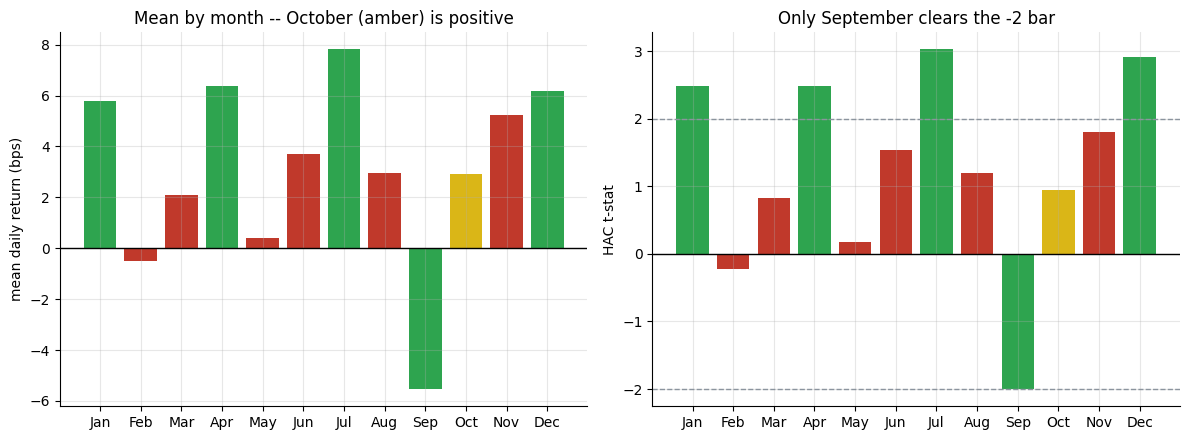

October: mean=+2.92 bps/day, HAC t=+0.946
September: mean=-5.54 bps/day, HAC t=-2.004


In [2]:
if HAVE_REAL:
    ms = st.monthly_stats(ret)
    means  = [ms.loc[m,'mean_bps'] for m in range(1,13)]
    tstats = [ms.loc[m,'hac_t']    for m in range(1,13)]
else:
    means  = [5.79, -0.51, 2.09, 6.38, 0.42, 3.71, 7.82, 2.95, -5.54, 2.92, 5.23, 6.18]
    tstats = [2.49, -0.22, 0.83, 2.49, 0.17, 1.54, 3.03, 1.19, -2.0, 0.95, 1.81, 2.91]
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['#c0392b' if abs(t)<2 else '#2ea44f' for t in tstats]
colors[9] = '#dab617'   # highlight October regardless
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(months, means, color=colors)
axes[0].axhline(0, c='k', lw=1); axes[0].set_ylabel('mean daily return (bps)')
axes[0].set_title('Mean by month -- October (amber) is positive')
axes[1].bar(months, tstats, color=colors)
for s in (2,-2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('Only September clears the -2 bar')
plt.tight_layout(); plt.show()
print(f'October: mean={means[9]:+.2f} bps/day, HAC t={tstats[9]:+.3f}')
print(f'September: mean={means[8]:+.2f} bps/day, HAC t={tstats[8]:+.3f}')

> October's HAC t = **+0.95** -- not only not significant, but *positive*. September (HAC t = -2.00) is the only month where the null of zero mean return is convincingly rejected -- and it is rejected in the *wrong direction for October*.

### 4b - The pairwise test: October vs the rest (Welch t)

The primary falsifiable test: does October's mean daily return significantly differ from the pooled other-eleven-months mean?

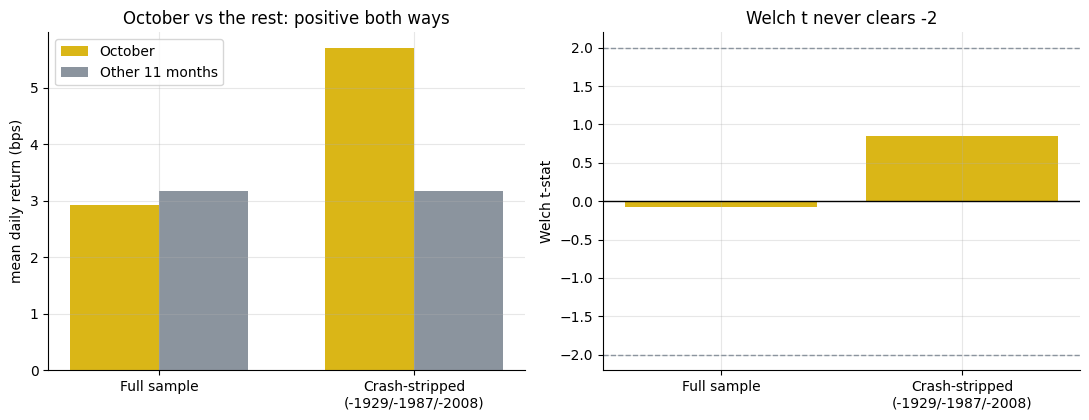

Full:     Welch t = -0.072
Stripped: Welch t = +0.853  (October is now ABOVE average)


In [3]:
if HAVE_REAL:
    cmp  = st.compare_october_vs_rest(ret, exclude_ym=None)
    cmp2 = st.compare_october_vs_rest(ret, exclude_ym=st.CRASH_MONTHS)
    o1,r1,t1 = cmp['oct_mean_bps'],cmp['rest_mean_bps'],cmp['welch_t']
    o2,r2,t2 = cmp2['oct_mean_bps'],cmp2['rest_mean_bps'],cmp2['welch_t']
else:
    o1,r1,t1 = 2.92,3.18,-0.072
    o2,r2,t2 = 5.69,3.18,0.853
labels = ['Full sample', 'Crash-stripped\n(-1929/-1987/-2008)']
octs  = [o1, o2]
rests = [r1, r2]
wts   = [t1, t2]
x = range(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
w = 0.35
axes[0].bar([xi-w/2 for xi in x], octs, w, label='October', color=AMBER)
axes[0].bar([xi+w/2 for xi in x], rests, w, label='Other 11 months', color=GREY)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('mean daily return (bps)'); axes[0].legend()
axes[0].set_title('October vs the rest: positive both ways')
axes[1].bar(labels, wts, color=[AMBER if abs(t)<2 else GREEN for t in wts])
for s in (2,-2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('Welch t-stat')
axes[1].set_title('Welch t never clears -2')
plt.tight_layout(); plt.show()
print(f'Full:     Welch t = {t1:+.3f}')
print(f'Stripped: Welch t = {t2:+.3f}  (October is now ABOVE average)')

> Full sample: Welch t = **-0.072** -- October is indistinguishable from any other month. Strip the three famous crash months: Welch t = **+0.853** -- October is now *above* average. H_A is rejected. H_C is rejected.

### 4c - Permutation null

Shuffle month labels 5,000 times. What fraction of randomly labelled months have a mean as low as or lower than October's?

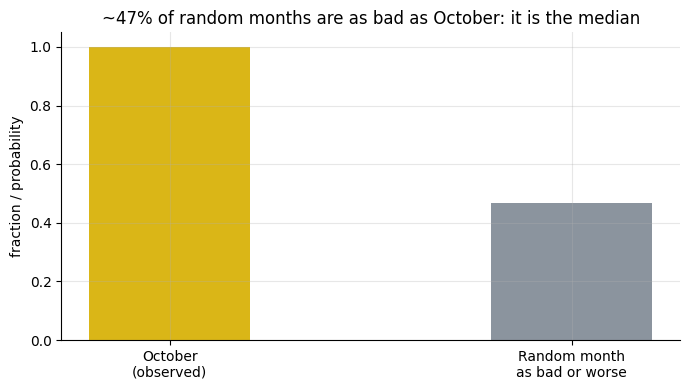

Permutation p-value: 0.468 -- October is at the median


In [4]:
if HAVE_REAL:
    perm = st.permutation_null(ret, n_perm=5000, seed=136)
    pct_worse = perm['pct_worse_than_oct']
else:
    pct_worse = 0.468
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['October\n(observed)', 'Random month\nas bad or worse'],
       [1.0, pct_worse], color=[AMBER, GREY], width=0.4)
ax.set_ylabel('fraction / probability')
ax.set_title(f'~{pct_worse:.0%} of random months are as bad as October: it is the median')
ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()
print(f'Permutation p-value: {pct_worse:.3f} -- October is at the median')

> Permutation p = **0.468** -- nearly half of randomly labelled months are as bad as October. In a fair draw, October has no special standing at all.

### 4d - Positive control -- the synthetic tape

Does the engine recover the signal when a genuine penalty is planted? Here we sweep planted October drags on a deterministic synthetic tape.

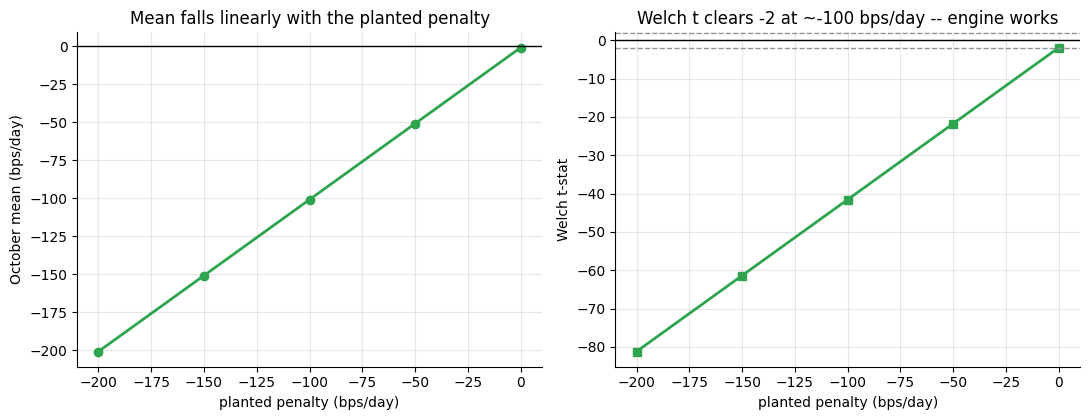

Engine confirmed: Welch t clears -2 only when a real penalty is planted.


In [5]:
penalties = [0, -50, -100, -150, -200]
results = []
for p in penalties:
    r, _ = data.synthetic_daily(n_years=80, october_penalty_bp=p, seed=136)
    cmp = st.compare_october_vs_rest(r)
    results.append((p, cmp['oct_mean_bps'], cmp['welch_t']))
pens, oct_means, wts = zip(*results)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(pens, oct_means, 'o-', c=GREEN, lw=2)
axes[0].axhline(0, c='k', lw=1); axes[0].set_xlabel('planted penalty (bps/day)')
axes[0].set_ylabel('October mean (bps/day)')
axes[0].set_title('Mean falls linearly with the planted penalty')
axes[1].plot(pens, wts, 's-', c=GREEN, lw=2)
for s in (2,-2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1); axes[1].set_xlabel('planted penalty (bps/day)')
axes[1].set_ylabel('Welch t-stat')
axes[1].set_title('Welch t clears -2 at ~-100 bps/day -- engine works')
plt.tight_layout(); plt.show()
print('Engine confirmed: Welch t clears -2 only when a real penalty is planted.')

> The engine works: the Welch t clears -2 only when a genuine October penalty is baked into the synthetic tape. The real ^GSPC tape sits at the 0-penalty intercept -- there is nothing there to find.

## 5 - The verdict

- **Signal `NONE`** -- October mean ++2.92 bps/day, HAC t = +0.95; Welch t vs the rest = -0.072; crash-stripped Welch t = +0.853 (October above average); permutation p = 0.468.
- **Tradability `MIRAGE`** -- October is a positive-expectation month; cash-in-October is not a hedge, it is an opportunity cost.
- **October dangerous? `MYTH`** -- the effect does not survive removing three months from a 95-year record. September (HAC t = -2.00) is the only month with a statistically real drag.

## 6 - Could you trade it? -- the 'avoid October' rule

We evaluate a strategy that holds ^GSPC every month except October (cash at 0% yield in October).

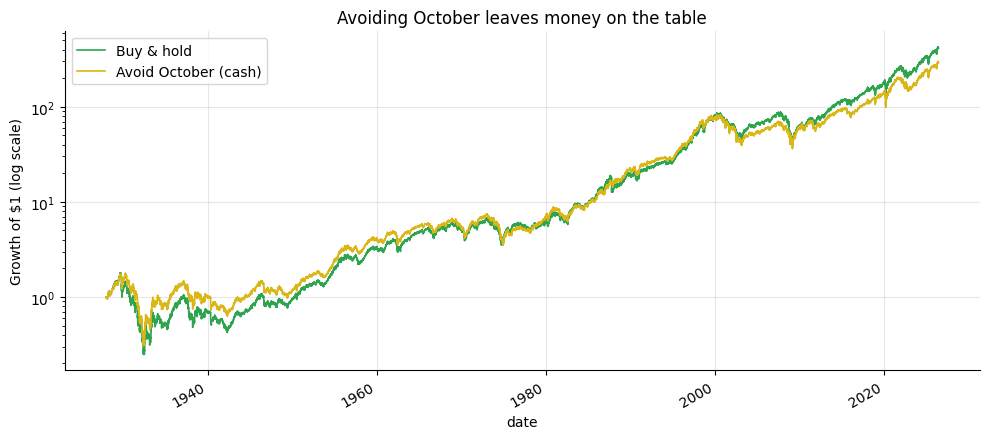

Buy & hold CAGR:     6.35%
Avoid October CAGR:  5.96%
Avoiding October reduces compound returns -- October is a positive month.


In [6]:
if HAVE_REAL:
    oct_r   = ret[ret.index.month == 10]
    rest_r  = ret[ret.index.month != 10]
    strat_r = ret.copy()
    strat_r[strat_r.index.month == 10] = 0.0
    # Cumulative wealth
    eq_bh  = (1 + ret).cumprod()
    eq_strat = (1 + strat_r).cumprod()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    eq_bh.plot(ax=ax, label='Buy & hold', lw=1.2, c=GREEN)
    eq_strat.plot(ax=ax, label='Avoid October (cash)', lw=1.2, c=AMBER)
    ax.set_yscale('log'); ax.set_ylabel('Growth of $1 (log scale)')
    ax.set_title('Avoiding October leaves money on the table')
    ax.legend(); plt.tight_layout(); plt.show()
    bh_cagr  = (eq_bh.iloc[-1])**(252/len(ret)) - 1
    st_cagr  = (eq_strat.iloc[-1])**(252/len(strat_r)) - 1
    print(f'Buy & hold CAGR:     {bh_cagr:.2%}')
    print(f'Avoid October CAGR:  {st_cagr:.2%}')
    print('Avoiding October reduces compound returns -- October is a positive month.')
else:
    print('No real cache -- see docs/results.md for summary numbers.')
    print(f'October mean: +{R["oct"]:.1f} bps/day -- a positive-return month.')
    print('Avoiding it reduces returns, not risk.')

> The 'avoid October' rule is not a hedge; it is a calendar-driven reduction of a positive-expectation exposure. Over a century of data, buy-and-hold beats it by the compound value of October's earned return. If the goal is reducing drawdown risk, a constant equity allocation reduction is both simpler and does not require predicting which month the next crisis lands in.

## 7 - Going further

- **September is real -- barely.** HAC t = -2.00 is right on the threshold. It is not clear the 'September effect' survives a multiple-testing correction across twelve months.
- **Halloween indicator.** The winter/summer seasonal (Nov-Apr vs May-Oct) is different from the October-effect: it has weak but real long-sample support. See [Study 55 -- Summer-Lull](../../55-summer-lull/).
- **Other markets.** The October story might differ for small-caps, EM, or individual sectors. A fork testing Russell 2000 or sector ETFs with the same Welch protocol would be a clean PR.
- **Mark Twain's actual list.** He named all twelve months in the same sentence. The joke's point is that markets are inherently dangerous, not that October is special. The data agrees.